In [60]:
import pandas as pd
import scipy.stats as st
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

### Загрузка данных

In [16]:
# Основная группа пользователей из системы сплитования

In [17]:
groups = pd.read_csv("groups.csv", sep=';')

In [18]:
groups.head()

,id,grp
0,1489,B
1,1627,A
2,1768,B
3,1783,B
4,1794,A


In [19]:
groups.isna().sum()

id     0
grp    0
dtype: int64

In [20]:
groups.duplicated().sum()

np.int64(0)

In [21]:
groups.grp.value_counts()

grp
B    59813
A    14671
Name: count, dtype: int64

Пользователей из группы контрольной примерно в 4 раза больше чем пользователей из тестовой группы 

In [22]:
# Дополнительная группа с пользователями, пришла позже

In [23]:
group_add = pd.read_csv("group_add.csv")

In [24]:
group_add.head()

,id,grp
0,5694584,B
1,5694830,B
2,5695057,B
3,5698872,B
4,5699067,B


In [25]:
group_add.isna().sum()

id     0
grp    0
dtype: int64

In [26]:
group_add.duplicated().sum()

np.int64(0)

In [27]:
group_add.grp.value_counts()

grp
B    70
A    22
Name: count, dtype: int64

Как и в основной группе большинство пользователей принадлежат к контрольой группе

In [28]:
# Соеднияем наши группы

In [29]:
df = pd.concat([groups, group_add])

In [30]:
df.head()

,id,grp
0,1489,B
1,1627,A
2,1768,B
3,1783,B
4,1794,A


In [31]:
# Пользователи которые приняли участие в эксперименте

In [32]:
active = pd.read_csv("active_studs.csv")

In [33]:
active.head()

,student_id
0,581585
1,5723133
2,3276743
3,4238589
4,4475369


In [34]:
active.isna().sum()

student_id    0
dtype: int64

In [35]:
active.duplicated().sum()

np.int64(0)

In [36]:
# Выручка каждого пользователя

In [37]:
checks = pd.read_csv("checks.csv", sep=";")

In [38]:
checks.head()

,student_id,rev
0,1627,990.0
1,3185,690.0
2,25973,690.0
3,26280,690.0
4,100300,990.0


In [39]:
checks.isna().sum()

student_id    0
rev           0
dtype: int64

In [40]:
checks.duplicated().sum()

np.int64(0)

In [41]:
checks = checks.rename(columns={'student_id': 'id'})

In [42]:
# Добавляем информацию о выручке
df = df.merge(checks, how='left', on='id')

In [43]:
df.fillna({'rev': 0}, inplace=True)

In [44]:
df.head()

,id,grp,rev
0,1489,B,0.0
1,1627,A,990.0
2,1768,B,0.0
3,1783,B,0.0
4,1794,A,0.0


In [45]:
control = df[df.grp=='A'].rev
test = df[df.grp=='B'].rev

#### Посмотрим на выборки

In [46]:
# Различается ли разброс данных в группах

In [47]:
st.levene(control, test)

LeveneResult(statistic=np.float64(2.998766927253985), pvalue=np.float64(0.08333204995153062))

В группах есть значимые отличия в разбросе данных

In [48]:
st.normaltest(control)

NormaltestResult(statistic=np.float64(34722.67771541179), pvalue=np.float64(0.0))

In [49]:
st.normaltest(test)

NormaltestResult(statistic=np.float64(121311.8641665426), pvalue=np.float64(0.0))

Распределния выручки не являются нормальными у обеих групп

In [50]:
# Посмотрим нет ли экстремальных значений

In [51]:
control.describe()

count    14693.000000
mean         6.268019
std        100.790849
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max       3660.000000
Name: rev, dtype: float64

In [52]:
test.describe()

count    59883.000000
mean         8.036171
std        113.249998
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max       4650.000000
Name: rev, dtype: float64

В группах отстуствуют экстремальные значения, имеются различия в разбросе данных, можем начать проводить эксперминты

Система сплитования распределила большинство пользователей в контрольную группу, 
возможно произошла <br> ошибка в распределение. Второй вариант, что эксперимент длился небольшой отрезок времени и 
пользователей контрольной <br> группы не успели набрать для полноты эксперимента

### Эксперименты

Определим основные метрики

Так как мы меняем механику оплаты, нас будет интересовать стало ли больше пользователей оплачивать услуги на сайте?<br>
Можем сделать вывод что целевой метрикой является – Конверсия в оплату (CR) (сколько людей в итоге нажали кнопку "купить").
<br><br>
Чтобы нам понять, не будет ли эксперимент убыточный , определим метрику безопасности, которая скажет нам что тест негативно влияет на другие показатели. 
<br>Возьмем метрику ARPPU (сколько денег в среднем тратит платящий пользователь). Будет ли новая механика стимулировать покапать еще больше услуг или наоборот ее функционал слишком сложен и удобен только для мелких покупок?
<br><br>
Дополнительной метрикой будет являться ARPU (сколько денег в среднем тратит пользователь).

#### Сравним группы по конверсии в оплату используя критерий Хи-квадрат

In [74]:
buy_A = (control > 0).sum()
nobuy_A = (control == 0).sum()

buy_B = (test > 0).sum()
nobuy_B = (test == 0).sum()

table = [[buy_A, nobuy_A], [buy_B, nobuy_B]]
table

[[np.int64(107), np.int64(14586)], [np.int64(434), np.int64(59449)]]

In [75]:
chi2, p_val, dof, ex = st.chi2_contingency(table)
print(f"p-value для Конверсии: {p_val}")

p-value для Конверсии: 1.0


Критерий Хи-квадрат, рассчитанный на полных выборках сплитования, показал $p\text{-value} = 1.0$. Это свидетельствует о том, что в масштабах всей аудитории платформы фича не изменила общую конверсию в покупку.

#### Применяем Бутстрап для оценки значимости различий в метриках ARPU и ARPPU

Функция Бутстрапа для расчета 95% доверительного интервала разницы средних

In [69]:
def bootstrap(sample1, sample2, n_bootstrap=5000):
    diff = []
    
    for _ in range(n_bootstrap):
        boot_1 = np.random.choice(sample1, size=len(sample1), replace=True)
        boot_2 = np.random.choice(sample2, size=len(sample2), replace=True)
        diff.append(np.mean(boot_2) - np.mean(boot_1))
        
    
    left_ci = np.quantile(diff, 0.025)
    right_ci = np.quantile(diff, 0.975)
    
    return left_ci, right_ci

In [71]:
# Расчет для метрики ARPU (Средний доход на одного пользователя) -
arpu_left, arpu_right = bootstrap(control, test)
print(f"95% Доверительный интервал для разницы ARPU: [{arpu_left:.2f}, {arpu_right:.2f}]")

95% Доверительный интервал для разницы ARPU: [-0.19, 3.61]


In [73]:
# Расчет для метрики ARPPU (Средний чек платящего пользователя) -
arppu_control = control[control > 0]
arppu_test = test[test > 0]

arppu_left, arppu_right = bootstrap(arppu_control, arppu_test)
print(f"95% Доверительный интервал для разницы ARPPU: [{arppu_left:.2f}, {arppu_right:.2f}]")

95% Доверительный интервал для разницы ARPPU: [71.78, 407.73]


#### Вывод по результатам тестирования: 

Конверсия в оплату (CR): Критерий Хи-квадрат, рассчитанный на полных выборках, включая неактивных пользователей, показал $p\text{-value} = 1.0$. Это говорит о том, что в масштабах всей аудитории новая механика оплаты не изменила долю платящих пользователей.<br>
<br>Выручка на пользователя (ARPU): Оценка разницы средних доходов методом Бутстрапа показала, что 95% доверительный интервал равен [-0.19, 3.61]. Так как интервал включает в себя ноль, мы делаем вывод, что статистически значимых различий по метрике ARPU между группами нет.<br>
<br>Средний чек платящих (ARPPU): Оценка разницы средних чеков методом Бутстрапа показала, что 95% доверительный интервал равен [71.78, 407.73]. Интервал не включает в себя ноль, что доказывает наличие статистически значимого роста среднего чека в тестовой группе. В среднем платящие пользователи из группы B тратят больше, чем пользователи из группы А. <br><br>Рекомендация для бизнеса:<br>Несмотря на то, что новая механика оплаты не привлекла новых покупателей (CR и ARPU не изменились значимо), она успешно стимулирует уже платящую аудиторию совершать более крупные покупки.С точки зрения экономики, фича эффективна для монетизации текущей базы. Рекомендуется раскатывать новую механику оплаты на всех пользователей.

### Функция расчета метрик

In [56]:
def update_metrics(df, path_add_df, revenue_df):

    add_df = pd.read_csv(path_add_df)
    add_df.columns = df.columns


    data = pd.concat([df, add_df], ignore_index=True)


    data = data.merge(revenue_df, how="left", on="id")


    data["rev"] = data["rev"].fillna(0)

    # Делим на группы
    A = data[data.grp == "A"]
    B = data[data.grp == "B"]

    # Считаем метрики
    ARPU_A = A.rev.mean()
    ARPU_B = B.rev.mean()

    ARPPU_A = A[A.rev > 0].rev.mean()
    ARPPU_B = B[B.rev > 0].rev.mean()

    CR_A = len(A[A["rev"] > 0]) / len(A)
    CR_B = len(B[B["rev"] > 0]) / len(B)

    metrics_df = pd.DataFrame(
        {
            "CR": [CR_A, CR_B],
            "ARPU": [ARPU_A, ARPU_B],
            "ARPPU": [ARPPU_A, ARPPU_B],
        },
        index=["A", "B"],
    )

    return metrics_df, data

In [57]:
metrics_df, full_data = update_metrics(groups, "group_add.csv", checks)

In [58]:
def plot_metrics(metrics_df, raw_data):
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))


    cr_percentages = metrics_df["CR"] * 100
    sns.barplot(
        x=cr_percentages.index, y=cr_percentages.values, ax=axes[0], palette="pastel"
    )
    axes[0].set_title("Конверсия в оплату (CR, %)")
    axes[0].set_ylabel("Процент платящих пользователей")
    axes[0].set_xlabel("Группа")
    

    for i, val in enumerate(cr_percentages.values):
        axes[0].text(i, val + 0.1, f"{val:.2f}%", ha="center", va="bottom", fontsize=11, weight='bold')

    # Распределение выручки по ВСЕМ (ARPU)

    sns.boxplot(x="grp", y="rev", data=raw_data, ax=axes[1], palette="muted")
    axes[1].set_title("Распределение выручки (ARPU)")
    axes[1].set_ylabel("Выручка в рублях")
    axes[1].set_xlabel("Группа")

    # Распределение только ПЛАТЯЩИХ (ARPPU)

    paying_data = raw_data[raw_data["rev"] > 0]
    
    # Распределение выручки
    sns.violinplot(x="grp", y="rev", data=paying_data, ax=axes[2], palette="deep", inner="quartile")
    axes[2].set_title("Форма распределения чеков платящих (ARPPU)")
    axes[2].set_ylabel("Сумма покупки в рублях")
    axes[2].set_xlabel("Группа")


    plt.tight_layout()
    plt.show()

/var/folders/vz/8ymk75s12ln27x7pfmf1jfx40000gn/T/ipykernel_2788/1904116344.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/var/folders/vz/8ymk75s12ln27x7pfmf1jfx40000gn/T/ipykernel_2788/1904116344.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="grp", y="rev", data=raw_data, ax=axes[1], palette="muted")
/var/folders/vz/8ymk75s12ln27x7pfmf1jfx40000gn/T/ipykernel_2788/1904116344.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x="grp", y="rev", data=paying_data, ax=axes[2], palette="deep", inner="quartile")


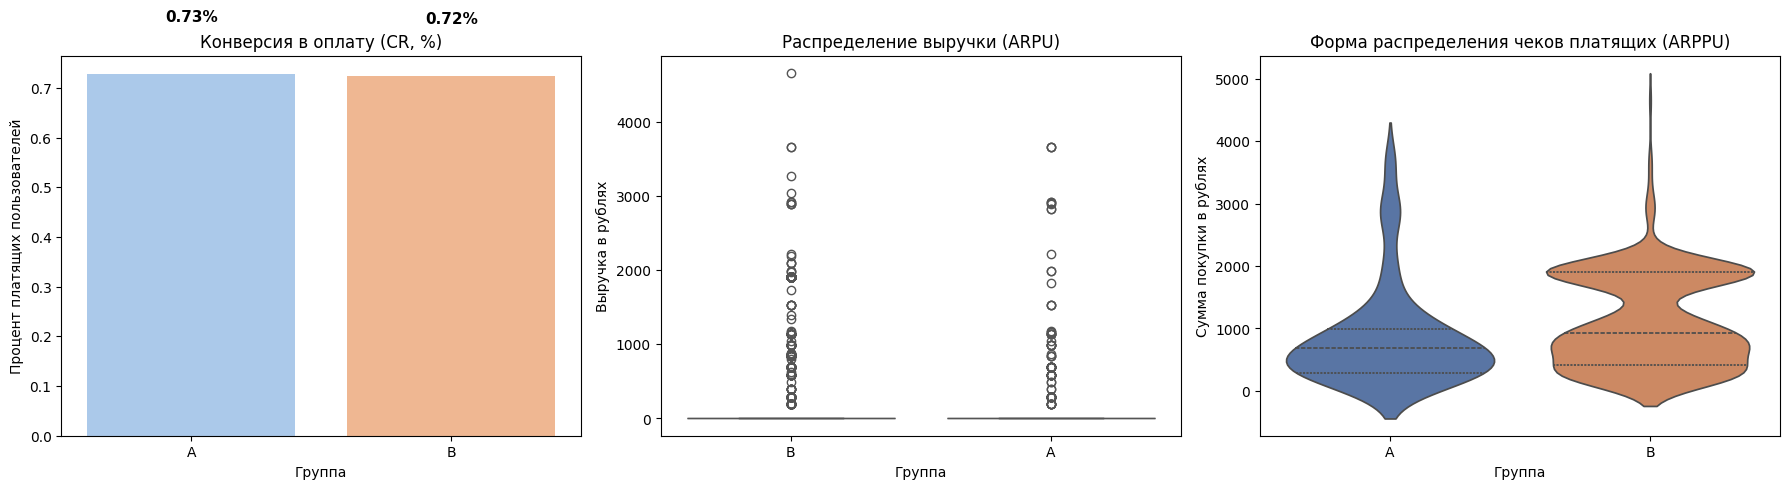

In [59]:
plot_metrics(metrics_df, full_data)